# 第 11 章　各種模型使用時機比較與效能提升策略

這是「醫學生的機器學習入門」第 11 章的配套 Notebook。可以直接在 Google Colab 執行（上方選單「執行階段 → 全部執行」），不需要另外安裝套件。

- 網站章節：`docs/chapters/11-model-selection.md`（網站上的「第 11 章」）
- 資料集：Breast Cancer Wisconsin Diagnostic（WDBC，scikit-learn 內建）、CDC Diabetes Health Indicators（UCI id 891，原始資料 CC0）
- 圖上的標籤用英文，是因為 Colab 預設沒有中文字型。
- **本例僅供學習，不構成臨床建議。**CDC 資料是自陳問卷，不是診斷資料。

第一步：匯入套件並印出版本。本 Notebook 以 Colab 的 scikit-learn 1.6.1 為相容底線，較新版本也能跑。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (train_test_split, cross_val_score, StratifiedKFold,
                                     KFold, GroupKFold, GridSearchCV, RandomizedSearchCV,
                                     validation_curve)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, average_precision_score,
                             precision_recall_curve, brier_score_loss, balanced_accuracy_score)
from sklearn.calibration import calibration_curve

print("numpy", np.__version__, "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__)
SEED = 42

numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1


## 1. 同一份資料、7 種模型：用交叉驗證公平比較

先用平衡的 WDBC（乳房腫塊細針抽吸的影像特徵，良性 vs 惡性）。每個模型都跑 **10 折分層交叉驗證（Stratified K-fold）**，報告 AUC 的平均 ± 標準差。需要標準化的模型（邏輯迴歸、SVM、神經網路）把 `StandardScaler` 放進 Pipeline，讓每一折只用訓練折來算平均與標準差，避免資料洩漏。

In [2]:
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
models = {
    "LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "NaiveBayes": GaussianNB(),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC()),
    "DecisionTree": DecisionTreeClassifier(random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=SEED),
    "MLP": make_pipeline(StandardScaler(),
                         MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=SEED)),
    "HistGB": HistGradientBoostingClassifier(random_state=SEED),
}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
scores = {name: cross_val_score(m, X, y, cv=cv, scoring="roc_auc") for name, m in models.items()}
summary = pd.DataFrame({"mean_AUC": {k: v.mean() for k, v in scores.items()},
                        "SD": {k: v.std() for k, v in scores.items()}}).sort_values("mean_AUC")
print(summary.round(3))

              mean_AUC     SD
DecisionTree     0.920  0.024
NaiveBayes       0.989  0.008
RandomForest     0.991  0.012
MLP              0.992  0.015
HistGB           0.992  0.011
LogReg           0.995  0.007
SVM (RBF)        0.996  0.005


輸出是每個模型 10 折 AUC 的平均與標準差。注意前幾名的差距（約 0.00x）比標準差（約 0.01）還小，所以不能說誰「最好」，只能說它們在這份資料上表現相近；決策樹則明顯落後。下面把每一折畫出來。

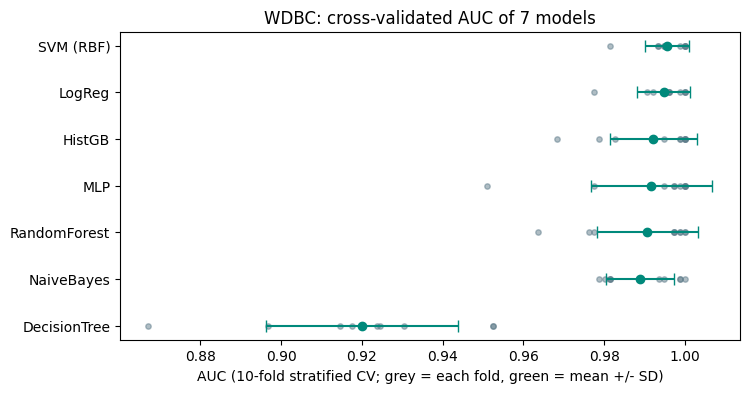

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for i, name in enumerate(summary.index):
    s = scores[name]
    ax.scatter(s, np.full(len(s), i), color="#607D8B", alpha=0.5, s=15)
    ax.errorbar(s.mean(), i, xerr=s.std(), fmt="o", color="#00897B", capsize=4)
ax.set_yticks(range(len(summary)), summary.index)
ax.set_xlabel("AUC (10-fold stratified CV; grey = each fold, green = mean +/- SD)")
ax.set_title("WDBC: cross-validated AUC of 7 models")
plt.show()

## 2. 三種切法：K-fold、Stratified K-fold、Group K-fold

用一個只有 10% 陽性的玩具資料看差別：普通 K-fold 每一折的陽性比例會亂跳，分層（stratified）版本則每折都維持約 10%。

In [4]:
y_toy = np.array([1] * 10 + [0] * 90)
X_toy = np.zeros((100, 1))
for name, splitter in [("KFold", KFold(5, shuffle=True, random_state=SEED)),
                       ("StratifiedKFold", StratifiedKFold(5, shuffle=True, random_state=SEED))]:
    rates = [y_toy[test].mean() for _, test in splitter.split(X_toy, y_toy)]
    print(f"{name:16s} positive rate in each test fold:", np.round(rates, 2))

KFold            positive rate in each test fold: [0.1 0.1 0.2 0.  0.1]
StratifiedKFold  positive rate in each test fold: [0.1 0.1 0.1 0.1 0.1]


接著是 **Group K-fold**：假設 20 位病人、每人 5 筆回診紀錄。用 GroupKFold 時，同一位病人的紀錄只會同時出現在訓練或測試其中一邊。

In [5]:
patient_id = np.repeat(np.arange(20), 5)          # 20 patients x 5 visits
X_visits = np.zeros((100, 1))
for fold, (tr, te) in enumerate(GroupKFold(n_splits=5).split(X_visits, groups=patient_id)):
    overlap = set(patient_id[tr]) & set(patient_id[te])
    print(f"fold {fold}: test patients {sorted(int(p) for p in set(patient_id[te]))}, overlap with train = {len(overlap)}")

fold 0: test patients [4, 9, 14, 19], overlap with train = 0
fold 1: test patients [5, 10, 15, 18], overlap with train = 0
fold 2: test patients [1, 6, 11, 16], overlap with train = 0
fold 3: test patients [2, 7, 12, 17], overlap with train = 0
fold 4: test patients [0, 3, 8, 13], overlap with train = 0


每一折的重疊病人數都是 0。如果改用普通 KFold，同一位病人的回診會同時出現在兩邊，模型等於「看過考題」，分數會虛高。

## 3. 超參數搜尋：GridSearchCV 與 RandomizedSearchCV

先留一份測試集完全不碰，只在訓練集內用交叉驗證挑 SVM 的 `C` 與 `gamma`。Pipeline 內的參數名稱寫成「步驟名__參數名」。

In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)
svm = make_pipeline(StandardScaler(), SVC())
grid = GridSearchCV(svm, {"svc__C": [0.1, 1, 10, 100], "svc__gamma": [0.001, 0.01, 0.1, 1]},
                    cv=StratifiedKFold(5, shuffle=True, random_state=SEED), scoring="roc_auc")
grid.fit(X_tr, y_tr)
print("best params:", grid.best_params_)
print("best CV AUC (inside training set):", round(grid.best_score_, 3))
print("AUC on untouched test set:", round(roc_auc_score(y_te, grid.decision_function(X_te)), 3))

best params: {'svc__C': 10, 'svc__gamma': 0.01}
best CV AUC (inside training set): 0.997
AUC on untouched test set: 0.999


`best_score_` 是在訓練集內挑出來的最佳分數，帶有「挑選過」的樂觀偏差；真正要報告的是最後一行，在從未參與挑選的測試集上的表現。

參數組合太多時改用隨機搜尋：給每個參數一個分布，只抽 `n_iter` 組來試。

In [7]:
from scipy.stats import randint
rand = RandomizedSearchCV(RandomForestClassifier(random_state=SEED),
                          {"n_estimators": randint(50, 300), "max_depth": [None, 3, 5, 8],
                           "min_samples_leaf": randint(1, 10)},
                          n_iter=10, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                          scoring="roc_auc", random_state=SEED)
rand.fit(X_tr, y_tr)
print("best params:", rand.best_params_)
print("best CV AUC:", round(rand.best_score_, 3),
      "| test AUC:", round(roc_auc_score(y_te, rand.predict_proba(X_te)[:, 1]), 3))

best params: {'max_depth': 5, 'min_samples_leaf': 7, 'n_estimators': 124}
best CV AUC: 0.989 | test AUC: 0.993


## 4. 不平衡資料：CDC 糖尿病指標

CDC Diabetes Health Indicators 來自 2015 年美國 BRFSS 電話問卷，約 25 萬人、21 個特徵，糖尿病（含前期）比例約 13.9%。全部下載約需 20–40 秒；為了讓 Notebook 跑得快，我們分層抽樣 2 萬人。

In [8]:
CDC_URL = "https://archive.ics.uci.edu/static/public/891/data.csv"
try:
    cdc = pd.read_csv(CDC_URL)
except Exception as e:
    raise RuntimeError("無法下載 CDC 資料，請確認網路後重試；或改用 ucimlrepo："
                       "from ucimlrepo import fetch_ucirepo; fetch_ucirepo(id=891)") from e
cdc = cdc.drop(columns=["ID"], errors="ignore")
cdc_sub, _ = train_test_split(cdc, train_size=20000, stratify=cdc["Diabetes_binary"], random_state=SEED)
Xd, yd = cdc_sub.drop(columns="Diabetes_binary"), cdc_sub["Diabetes_binary"]
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.25, stratify=yd, random_state=SEED)
print("subsample:", Xd.shape, "| prevalence:", round(yd.mean(), 3))
print("train:", Xd_tr.shape, "| test:", Xd_te.shape)

subsample: (20000, 21) | prevalence: 0.139
train: (15000, 21) | test: (5000, 21)


輸出顯示抽樣後仍維持約 13.9% 的陽性比例。先看「準確率陷阱」：一個永遠說「沒有糖尿病」的模型，準確率有多高？

In [9]:
dummy = DummyClassifier(strategy="most_frequent").fit(Xd_tr, yd_tr)
lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xd_tr, yd_tr)
for name, m in [("always-negative", dummy), ("logistic regression", lr)]:
    pred = m.predict(Xd_te)
    tn, fp, fn, tp = confusion_matrix(yd_te, pred).ravel()
    print(f"{name:20s} accuracy={(tp + tn) / len(yd_te):.3f}  sensitivity={tp / (tp + fn):.3f}  "
          f"balanced_acc={balanced_accuracy_score(yd_te, pred):.3f}")

always-negative      accuracy=0.861  sensitivity=0.000  balanced_acc=0.500
logistic regression  accuracy=0.866  sensitivity=0.164  balanced_acc=0.572


永遠猜陰性就有約 86% 準確率，但敏感度是 0。邏輯迴歸在預設閾值 0.5 下準確率只略高一點，敏感度卻很低——問題不在模型，而在閾值。

## 5. 閾值、2×2 表與醫學指標

寫一個小函式，把 2×2 表轉成醫學讀者熟悉的敏感度、特異度、PPV、NPV。規則：預測機率 ≥ 閾值就判陽性（網站互動 demo 用同一規則）。

In [10]:
def clinical_metrics(y_true, prob, t):
    pred = (prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {"threshold": t, "TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "sensitivity": round(tp / (tp + fn), 3), "specificity": round(tn / (tn + fp), 3),
            "PPV": round(tp / (tp + fp), 3) if tp + fp else np.nan, "NPV": round(tn / (tn + fn), 3)}

p_lr = np.round(lr.predict_proba(Xd_te)[:, 1], 3)   # rounded like the website demo
pd.DataFrame([clinical_metrics(yd_te, p_lr, t) for t in [0.14, 0.3, 0.5]])

,threshold,TP,FP,FN,TN,sensitivity,specificity,PPV,NPV
0,0.14,550,1215,147,3088,0.789,0.718,0.312,0.955
1,0.30,318,414,379,3889,0.456,0.904,0.434,0.911
2,0.50,114,87,583,4216,0.164,0.980,0.567,0.879


閾值從 0.5 降到 0.14（接近盛行率），敏感度大幅上升、特異度下降、PPV 也跟著降。這和網站上 ROC 滑桿 demo 同一閾值的數字應該一致。

把所有閾值畫在一起，就是 ROC 曲線；不平衡時再加看 PR 曲線。

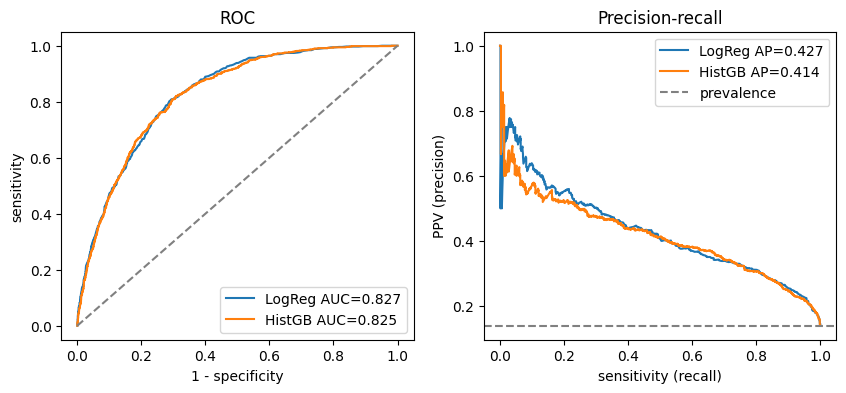

In [11]:
hgb = HistGradientBoostingClassifier(random_state=SEED).fit(Xd_tr, yd_tr)
p_hgb = hgb.predict_proba(Xd_te)[:, 1]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4))
for p, name in [(p_lr, "LogReg"), (p_hgb, "HistGB")]:
    fpr, tpr, _ = roc_curve(yd_te, p)
    a1.plot(fpr, tpr, label=f"{name} AUC={roc_auc_score(yd_te, p):.3f}")
    prec, rec, _ = precision_recall_curve(yd_te, p)
    a2.plot(rec, prec, label=f"{name} AP={average_precision_score(yd_te, p):.3f}")
a1.plot([0, 1], [0, 1], "--", color="grey")
a2.axhline(yd_te.mean(), ls="--", color="grey", label="prevalence")
a1.set(xlabel="1 - specificity", ylabel="sensitivity", title="ROC")
a2.set(xlabel="sensitivity (recall)", ylabel="PPV (precision)", title="Precision-recall")
a1.legend(); a2.legend(); plt.show()

兩個模型在單一測試集上的 AUC 很接近。要判斷差距是否穩定，應該在訓練集上做交叉驗證並看標準差：

In [12]:
cv5 = StratifiedKFold(5, shuffle=True, random_state=SEED)
for name, m in [("LogReg", make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))),
                ("HistGB", HistGradientBoostingClassifier(random_state=SEED))]:
    s = cross_val_score(m, Xd_tr, yd_tr, cv=cv5, scoring="roc_auc")
    print(f"{name}: CV AUC {s.mean():.3f} +/- {s.std():.3f}")

LogReg: CV AUC 0.819 +/- 0.010


HistGB: CV AUC 0.816 +/- 0.006


兩者平均 AUC 的差距落在標準差範圍內，表示在這份資料上看不出誰穩定勝出；此時較簡單、可解釋的邏輯迴歸通常是合理選擇。

## 6. class_weight 與校準

`class_weight="balanced"` 讓模型更重視少數類別。它會把預測機率整體往上推：排序能力（AUC）幾乎不變，但機率不再代表真實風險。

AUC   plain: 0.827 | balanced: 0.828
Brier plain: 0.098 | balanced: 0.177
mean predicted risk plain: 0.14 | balanced: 0.388 | observed prevalence: 0.139


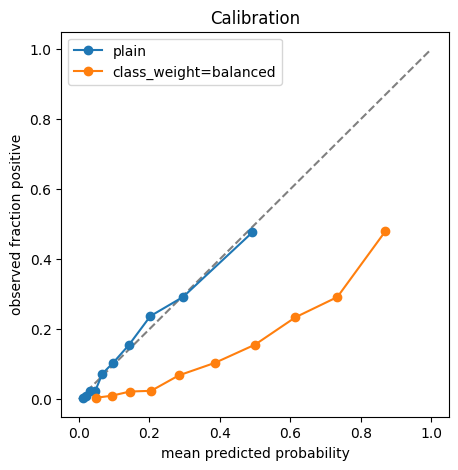

In [13]:
lr_bal = make_pipeline(StandardScaler(),
                       LogisticRegression(max_iter=1000, class_weight="balanced")).fit(Xd_tr, yd_tr)
p_bal = lr_bal.predict_proba(Xd_te)[:, 1]
print("AUC   plain:", round(roc_auc_score(yd_te, p_lr), 3), "| balanced:", round(roc_auc_score(yd_te, p_bal), 3))
print("Brier plain:", round(brier_score_loss(yd_te, p_lr), 3), "| balanced:", round(brier_score_loss(yd_te, p_bal), 3))
print("mean predicted risk plain:", round(p_lr.mean(), 3), "| balanced:", round(p_bal.mean(), 3),
      "| observed prevalence:", round(yd_te.mean(), 3))
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "--", color="grey")
for p, name in [(p_lr, "plain"), (p_bal, "class_weight=balanced")]:
    frac, mean_p = calibration_curve(yd_te, p, n_bins=10, strategy="quantile")
    ax.plot(mean_p, frac, "o-", label=name)
ax.set(xlabel="mean predicted probability", ylabel="observed fraction positive", title="Calibration")
ax.legend(); plt.show()

Brier 分數越低越好。加權版的平均預測風險遠高於實際盛行率（約 14%），校準曲線整條落在對角線下方：它適合「排序／篩選」，但不適合直接告訴病人「你的風險是 X%」。

## 7. 偏差與變異：驗證曲線

改變決策樹的最大深度，比較訓練分數與交叉驗證分數。

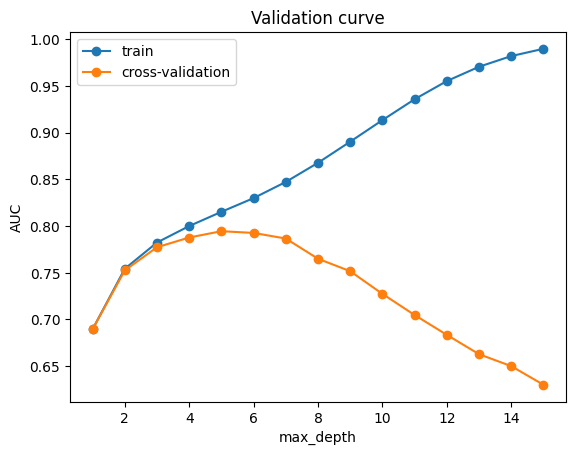

best depth by CV: 5


In [14]:
depths = np.arange(1, 16)
tr_s, va_s = validation_curve(DecisionTreeClassifier(random_state=SEED), Xd_tr, yd_tr,
                              param_name="max_depth", param_range=depths, cv=cv5, scoring="roc_auc")
plt.plot(depths, tr_s.mean(1), "o-", label="train")
plt.plot(depths, va_s.mean(1), "o-", label="cross-validation")
plt.xlabel("max_depth"); plt.ylabel("AUC"); plt.legend(); plt.title("Validation curve")
plt.show()
print("best depth by CV:", depths[va_s.mean(1).argmax()])

深度小時兩條線都低（偏差大、配適不足）；深度大時訓練分數接近 1、驗證分數卻下滑（變異大、過擬合）。交叉驗證分數最高的深度就是這兩者的平衡點。

## 動手試試

1. 在第 5 節把閾值改成 0.2、0.25，觀察敏感度與 PPV 如何交換。如果這是「篩檢後再做 HbA1c 確認」的情境，你會選哪個閾值？為什麼？
2. 在第 1 節把 `StratifiedKFold` 的 `random_state` 改成 0 或 1 重跑，各模型的排名有沒有變？這告訴你單次分數差距的意義是什麼？
3. 在第 3 節的 GridSearchCV 裡把 `scoring` 改成 `"balanced_accuracy"`，最佳參數會不會改變？